In [ ]:
#  Cell 1: Setup – install and import everything
import sys, subprocess, pkg_resources, warnings, os
warnings.filterwarnings("ignore")

required = {
    "pandas", "numpy", "scikit-learn", "xgboost",
    "imblearn", "matplotlib", "seaborn", "joblib", "shap"
}
installed = {pkg.key for pkg in pkg_resources.working_set}
missing = [p for p in required if p not in installed]
if missing:
    subprocess.check_call([sys.executable, "-m", "pip", "install", *missing])

import numpy as np, pandas as pd, seaborn as sns, matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from imblearn.over_sampling import SMOTE
from sklearn.metrics import accuracy_score, f1_score, classification_report
from sklearn.ensemble import ExtraTreesClassifier
import xgboost as xgb, shap, joblib, packaging

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
print(" Libraries imported successfully.")


/tmp/ipython-input-4057510388.py:2: DeprecationWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html
  import sys, subprocess, pkg_resources, warnings, os


 Libraries imported successfully.


In [ ]:
#  Diagnostic: Check actual column names in your UNSW dataset
import pandas as pd

DATA_PATH = "UNSW_NB15_testing-set_converted.csv"
df = pd.read_csv(DATA_PATH)

print("Columns in dataset:")
print(df.columns.tolist())

print("\nFirst 5 rows:")
print(df.head())

print("\nData types:")
print(df.dtypes)


Columns in dataset:
['dur', 'proto', 'service', 'state', 'spkts', 'dpkts', 'sbytes', 'dbytes', 'rate', 'sload', 'dload', 'sloss', 'dloss', 'sinpkt', 'dinpkt', 'sjit', 'djit', 'swin', 'stcpb', 'dtcpb', 'dwin', 'tcprtt', 'synack', 'ackdat', 'smean', 'dmean', 'trans_depth', 'response_body_len', 'ct_src_dport_ltm', 'ct_dst_sport_ltm', 'is_ftp_login', 'ct_ftp_cmd', 'ct_flw_http_mthd', 'is_sm_ips_ports', 'attack_cat', 'label']

First 5 rows:
        dur proto service state  spkts  dpkts  sbytes  dbytes       rate  \
0  0.121478   tcp       -   FIN      6      4     258     172  74.087490   
1  0.649902   tcp       -   FIN     14     38     734   42014  78.473370   
2  1.623129   tcp       -   FIN      8     16     364   13186  14.170161   
3  1.681642   tcp     ftp   FIN     12     12     628     770  13.677108   
4  0.449454   tcp       -   FIN     10      6     534     268  33.373825   

        sload  ...  trans_depth  response_body_len  ct_src_dport_ltm  \
0  14158.9420  ...            0

In [ ]:
#  Cell 2: Load UNSW-NB15 dataset (fixed)
import pandas as pd, os
from google.colab import files

DATA_PATH = "UNSW_NB15_testing-set_converted.csv"

if not os.path.exists(DATA_PATH):
    print("Please upload UNSW_NB15_testing-set_converted.csv ")
    uploaded = files.upload()
    DATA_PATH = list(uploaded.keys())[0]

df = pd.read_csv(DATA_PATH)
print(" Dataset loaded:", DATA_PATH)
print("Shape:", df.shape)
display(df.head())
display(df.describe(include='all').T)

# Using 'label' as target (0 = normal, 1 = attack)
if "label" not in df.columns:
    raise KeyError("Expected a 'label' column for classification.")

print("\nClass distribution:")
print(df["label"].value_counts())


 Dataset loaded: UNSW_NB15_testing-set_converted.csv
Shape: (175341, 36)


,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,sload,...,trans_depth,response_body_len,ct_src_dport_ltm,ct_dst_sport_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,is_sm_ips_ports,attack_cat,label
0,0.121478,tcp,-,FIN,6,4,258,172,74.087490,14158.9420,...,0,0,1,1,0,0,0,0,Normal,0
1,0.649902,tcp,-,FIN,14,38,734,42014,78.473370,8395.1120,...,0,0,1,1,0,0,0,0,Normal,0
2,1.623129,tcp,-,FIN,8,16,364,13186,14.170161,1572.2719,...,0,0,1,1,0,0,0,0,Normal,0
3,1.681642,tcp,ftp,FIN,12,12,628,770,13.677108,2740.1790,...,0,0,1,1,1,1,0,0,Normal,0
4,0.449454,tcp,-,FIN,10,6,534,268,33.373825,8561.4990,...,0,0,2,1,0,0,0,0,Normal,0


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
dur,175341.0,NaN,NaN,NaN,1.359389,6.480249,0.0,0.000008,0.001582,0.668069,59.99999
proto,175341,133,tcp,79946,NaN,NaN,NaN,NaN,NaN,NaN,NaN
service,175341,13,-,94168,NaN,NaN,NaN,NaN,NaN,NaN,NaN
state,175341,9,INT,82275,NaN,NaN,NaN,NaN,NaN,NaN,NaN
spkts,175341.0,NaN,NaN,NaN,20.298664,136.887597,1.0,2.0,2.0,12.0,9616.0
dpkts,175341.0,NaN,NaN,NaN,18.969591,110.258271,0.0,0.0,2.0,10.0,10974.0
sbytes,175341.0,NaN,NaN,NaN,8844.843836,174765.644309,28.0,114.0,430.0,1418.0,12965233.0
dbytes,175341.0,NaN,NaN,NaN,14928.918564,143654.217718,0.0,0.0,164.0,1102.0,14655550.0
rate,175341.0,NaN,NaN,NaN,95406.18563,165400.975918,0.0,32.78614,3225.8066,125000.0,1000000.0
sload,175341.0,NaN,NaN,NaN,73454033.333701,188357446.780667,0.0,13053.339,879674.75,88888890.0,5988000300.0



Class distribution:
label
1    119341
0     56000
Name: count, dtype: int64


In [ ]:
#  Cell 3: Prepare features (X) and labels (y)
target_col = "label"
y = df[target_col].astype(int)  # binary (0 or 1)

# Drop both target + 'attack_cat' (not used for training)
X = df.drop(columns=[target_col, "attack_cat"])

categorical_cols = X.select_dtypes(include=["object", "category"]).columns.tolist()
numeric_cols = X.select_dtypes(include=[float, int]).columns.tolist()

print(" Feature split complete.")
print(f"Categorical columns ({len(categorical_cols)}): {categorical_cols}")
print(f"Numeric columns: {len(numeric_cols)}")


 Feature split complete.
Categorical columns (3): ['proto', 'service', 'state']
Numeric columns: 31


In [ ]:
#  Cell 4-Preprocessor (One-Hot + Scaling)
import sklearn
ohe_params = {'handle_unknown': 'ignore'}
if sklearn.__version__.startswith('1.'):
    ohe_params['sparse_output'] = False
else:
    ohe_params['sparse'] = False

numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])
categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("ohe", OneHotEncoder(**ohe_params))
])

preprocessor = ColumnTransformer([
    ("num", numeric_transformer, numeric_cols),
    ("cat", categorical_transformer, categorical_cols)
])
print(" Preprocessor ready.")


 Preprocessor ready.


In [ ]:
#  Cell 5-Split data
from collections import Counter
X_train_raw, X_test_raw, y_train_raw, y_test_raw = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)
print("Train:", X_train_raw.shape, " Test:", X_test_raw.shape)
print("Train class distribution:", Counter(y_train_raw))
print("Test  class distribution:", Counter(y_test_raw))


Train: (140272, 34)  Test: (35069, 34)
Train class distribution: Counter({1: 95472, 0: 44800})
Test  class distribution: Counter({1: 23869, 0: 11200})


In [ ]:
#  Cell 6-Preprocess + SMOTE
preprocessor.fit(X_train_raw)
X_train_pre = preprocessor.transform(X_train_raw)
X_test_pre  = preprocessor.transform(X_test_raw)

smote = SMOTE(random_state=RANDOM_STATE)
X_train_res, y_train_res = smote.fit_resample(X_train_pre, y_train_raw)

print(" Preprocessing + SMOTE done.")
print("After SMOTE class balance:", np.bincount(y_train_res))


 Preprocessing + SMOTE done.
After SMOTE class balance: [95472 95472]


In [ ]:
#  Cell 7-Train XGBoost
ver = packaging.version.parse(xgb.__version__)
print(f"Detected XGBoost version: {xgb.__version__}")

X_tr, X_val, y_tr, y_val = train_test_split(
    X_train_res, y_train_res, test_size=0.1, stratify=y_train_res, random_state=RANDOM_STATE
)

if ver < packaging.version.parse("3.0.0"):
    from xgboost.callback import EarlyStopping
    xgb_model = xgb.XGBClassifier(
        n_estimators=300, max_depth=8, learning_rate=0.1,
        subsample=0.8, colsample_bytree=0.8,
        eval_metric="logloss", random_state=RANDOM_STATE, n_jobs=-1
    )
    xgb_model.fit(X_tr, y_tr, eval_set=[(X_val, y_val)],
                  early_stopping_rounds=15 if "early_stopping_rounds" in xgb_model.fit.__code__.co_varnames else None,
                  verbose=False)
else:
    dtrain, dval = xgb.DMatrix(X_tr, label=y_tr), xgb.DMatrix(X_val, label=y_val)
    params = dict(max_depth=8, eta=0.1, subsample=0.8, colsample_bytree=0.8,
                  objective="binary:logistic", eval_metric="logloss", seed=42)
    evallist = [(dtrain, "train"), (dval, "eval")]
    booster = xgb.train(params, dtrain, num_boost_round=300,
                        evals=evallist, early_stopping_rounds=15, verbose_eval=False)
    class BoosterWrapper:
        def __init__(self, booster): self.booster = booster
        def predict(self, X): return (self.booster.predict(xgb.DMatrix(X)) > 0.5).astype(int)
    xgb_model = BoosterWrapper(booster)

print(" XGBoost trained successfully.")
y_pred = xgb_model.predict(X_test_pre)
print("Accuracy:", accuracy_score(y_test_raw, y_pred))
print("F1:", f1_score(y_test_raw, y_pred))
print(classification_report(y_test_raw, y_pred, digits=4))


Detected XGBoost version: 3.1.1
 XGBoost trained successfully.
Accuracy: 0.949670649291397
F1: 0.9629318492071826
              precision    recall  f1-score   support

           0     0.9166    0.9267    0.9216     11200
           1     0.9654    0.9605    0.9629     23869

    accuracy                         0.9497     35069
   macro avg     0.9410    0.9436    0.9423     35069
weighted avg     0.9498    0.9497    0.9497     35069



 ExtraTrees trained.


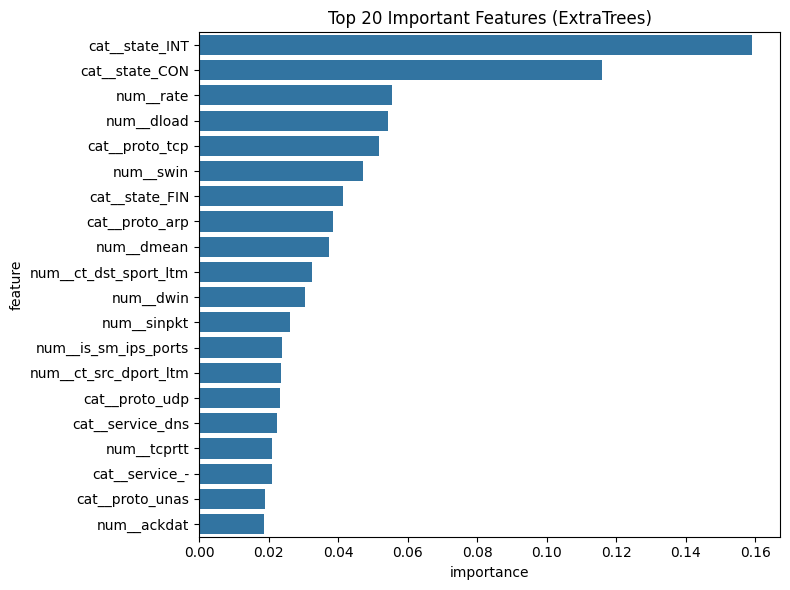

In [ ]:
#  Cell 8-Train ExtraTrees + Feature Importance
et_model = ExtraTreesClassifier(
    n_estimators=200, max_depth=12, min_samples_leaf=5,
    random_state=RANDOM_STATE, n_jobs=-1, class_weight="balanced"
)
et_model.fit(X_train_res, y_train_res)

print(" ExtraTrees trained.")
fi = pd.DataFrame({
    "feature": preprocessor.get_feature_names_out(),
    "importance": et_model.feature_importances_
}).sort_values("importance", ascending=False).head(20)

plt.figure(figsize=(8,6))
sns.barplot(x="importance", y="feature", data=fi)
plt.title("Top 20 Important Features (ExtraTrees)")
plt.tight_layout()
plt.show()


<Figure size 640x480 with 0 Axes>

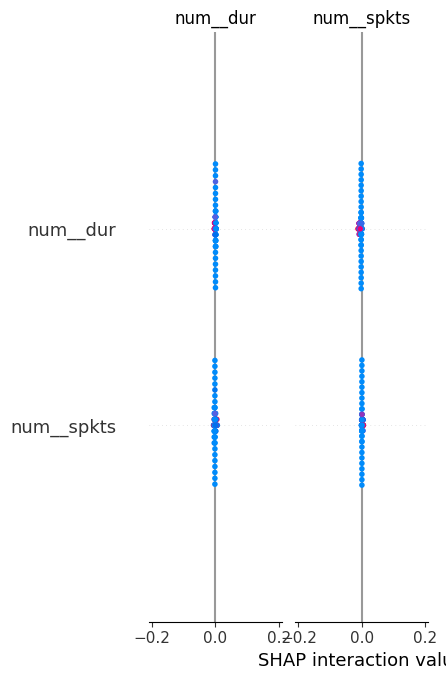

 SHAP explanation done.


In [ ]:
# Cell 9-SHAP Explainability
shap.initjs()
explainer = shap.TreeExplainer(et_model)
idx = np.random.choice(range(X_test_pre.shape[0]), min(100, X_test_pre.shape[0]), replace=False)
X_sample = X_test_pre[idx]
shap_values = explainer.shap_values(X_sample)

if isinstance(shap_values, list):
    shap_data = shap_values[1] if len(shap_values) > 1 else shap_values[0]
else:
    shap_data = shap_values

plt.figure()
shap.summary_plot(shap_data, X_sample, feature_names=preprocessor.get_feature_names_out(), show=True)
joblib.dump({"explainer": explainer, "values": shap_data}, "/content/unsw_shap_artifact.joblib")
print(" SHAP explanation done.")


In [ ]:
#  Cell 10-Cross-dataset Evaluation (Optional)
other_path = "UNSW_NB15_testing-set_converted.csv"
if os.path.exists(other_path):
    df2 = pd.read_csv(other_path)
    if "class" in df2.columns:
        y2 = df2["class"].apply(lambda x: 0 if str(x).lower()=="normal" else 1)
        X2 = df2.drop(columns=["class"])
        X2_pre = preprocessor.transform(X2)
        y2_pred = et_model.predict(X2_pre)
        print("Cross-dataset Accuracy:", accuracy_score(y2, y2_pred))
        print("Cross-dataset F1:", f1_score(y2, y2_pred))
else:
    print(" No UNSW_NB15_testing-set_converted dataset found. Skipping cross-dataset test.")


In [ ]:
#  Cell 11-Model Comparison
models = {"XGBoost": xgb_model, "ExtraTrees": et_model}
res = {}
for name, model in models.items():
    y_pred = model.predict(X_test_pre)
    acc, f1s = accuracy_score(y_test_raw, y_pred), f1_score(y_test_raw, y_pred)
    res[name] = {"Accuracy": acc, "F1": f1s}
    print(f"\n{name}: Accuracy={acc:.4f}, F1={f1s:.4f}")
display(pd.DataFrame(res).T)



XGBoost: Accuracy=0.9497, F1=0.9629

ExtraTrees: Accuracy=0.8543, F1=0.8849


,Accuracy,F1
XGBoost,0.949671,0.962932
ExtraTrees,0.854344,0.884950


In [ ]:
#  Cell 12-Save Models & Preprocessor
os.makedirs("/content/unsw_models", exist_ok=True)
joblib.dump(xgb_model, "/content/unsw_models/xgb_model.joblib")
joblib.dump(et_model, "/content/unsw_models/et_model.joblib")
joblib.dump(preprocessor, "/content/unsw_models/preprocessor.joblib")
print(" Models saved in /content/unsw_models/")


 Models saved in /content/unsw_models/


,Model,Train Acc,Test Acc,Train F1,Test F1,Acc Diff,F1 Diff
0,XGBoost,0.973366,0.949671,0.980396,0.962932,0.023695,0.017464
1,ExtraTrees,0.854597,0.854344,0.885006,0.884950,0.000252,0.000056


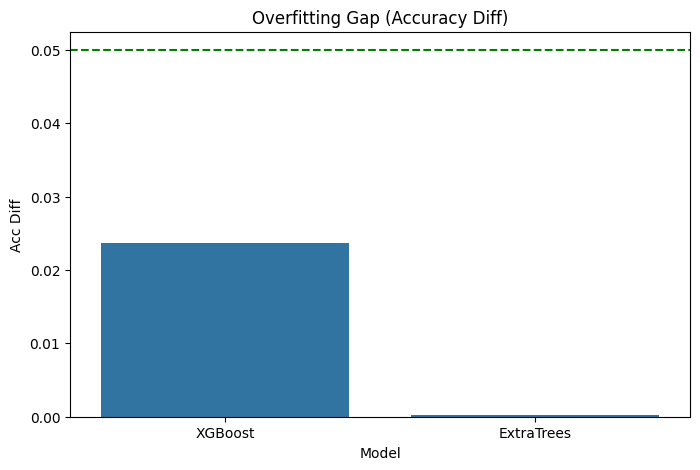

XGBoost → AccDiff=0.024, F1Diff=0.017
 No overfitting detected.
ExtraTrees → AccDiff=0.000, F1Diff=0.000
 No overfitting detected.


In [ ]:
#  Cell 13-Overfitting Check
models = {"XGBoost": xgb_model, "ExtraTrees": et_model}
rows=[]
for name, m in models.items():
    y_tr_pred = m.predict(X_train_pre)
    y_te_pred = m.predict(X_test_pre)
    train_acc, test_acc = accuracy_score(y_train_raw,y_tr_pred), accuracy_score(y_test_raw,y_te_pred)
    train_f1, test_f1   = f1_score(y_train_raw,y_tr_pred), f1_score(y_test_raw,y_te_pred)
    rows.append({"Model":name,"Train Acc":train_acc,"Test Acc":test_acc,
                 "Train F1":train_f1,"Test F1":test_f1,
                 "Acc Diff":train_acc-test_acc,"F1 Diff":train_f1-test_f1})
df_check=pd.DataFrame(rows)
display(df_check)

plt.figure(figsize=(8,5))
sns.barplot(x="Model",y="Acc Diff",data=df_check)
plt.title("Overfitting Gap (Accuracy Diff)")
plt.axhline(0.05,color="green",ls="--")
plt.show()

for _,r in df_check.iterrows():
    print(f"{r['Model']} → AccDiff={r['Acc Diff']:.3f}, F1Diff={r['F1 Diff']:.3f}")
    if abs(r['Acc Diff'])<0.05 and abs(r['F1 Diff'])<0.05:
        print(" No overfitting detected.")
    else:
        print(" Slight or possible overfitting.")


In [ ]:
#  Cell 14 — UNSW-NB15 Sample Prediction Demo (XGBoost + ExtraTrees only)
import pandas as pd, numpy as np
from collections import Counter
import os

print("--- Predictions for UNSW-NB15 Sample Demo ---")

#  1. Load the dataset
unsw_path = "/content/UNSW_NB15_testing-set_converted.csv"

if not os.path.exists(unsw_path):
    raise FileNotFoundError(" File 'UNSW_NB15_testing-set_converted.csv' not found. Upload it to /content/ first.")

unsw_df = pd.read_csv(unsw_path)
print(f" Dataset loaded successfully: {unsw_df.shape[0]} rows, {unsw_df.shape[1]} columns")

#  2. Remove 'class' column if it exists (for prediction only)
if "class" in unsw_df.columns:
    X_unsw = unsw_df.drop(columns=["class"])
else:
    X_unsw = unsw_df.copy()

#  3. Randomly sample N flows for testing (e.g., 10)
sample_df = X_unsw.sample(n=10, random_state=42)
print("\n🔹 10 random network flows selected for prediction demo.")

#  4. Preprocess the sample
try:
    sample_pre = preprocessor.transform(sample_df)
except Exception as e:
    raise ValueError(f" Preprocessing failed: {e}")

#  5. Predict using only XGBoost and ExtraTrees models
selected_models = {"XGBoost": xgb_model, "ExtraTrees": et_model}

for name, model in selected_models.items():
    preds = model.predict(sample_pre)
    print(f"\n{name} predicted class distribution:")
    print(Counter(preds))
    print("Predicted labels (0 = Normal, 1 = Attack):", preds.tolist())

print("\n Prediction demo completed successfully.")


--- Predictions for UNSW-NB15 Sample Demo ---
 Dataset loaded successfully: 175341 rows, 36 columns

🔹 10 random network flows selected for prediction demo.

XGBoost predicted class distribution:
Counter({np.int64(0): 5, np.int64(1): 5})
Predicted labels (0 = Normal, 1 = Attack): [0, 1, 1, 0, 0, 1, 1, 1, 0, 0]

ExtraTrees predicted class distribution:
Counter({np.int64(0): 7, np.int64(1): 3})
Predicted labels (0 = Normal, 1 = Attack): [0, 1, 0, 0, 0, 1, 1, 0, 0, 0]

 Prediction demo completed successfully.
